In [2]:
# import libraries 
import os,warnings,cartopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from matplotlib.ticker import MultipleLocator

import xarray as xr
import pandas as pd
from datetime import datetime
from scipy import stats, signal
from scipy.stats import false_discovery_control

warnings.filterwarnings('ignore') # Turns off warnings

# Read in and Prepare Data

In [3]:
ds = xr.open_dataset('storm_rainfall_rates.nc')

lat_mask = (ds.lat >= 25) & (ds.lat <= 49)
lon_mask = (ds.lon >= -105) & (ds.lon <= -67)

rain = ds.sel(lat=lat_mask, lon=lon_mask)
rain = rain.where(rain != 0)

del ds

### Calculate Rain Rate

In [4]:
rain_rate = (rain.rain / rain.hits).where(rain.hits > 0)

### Subset to first 15 years and last 15 years

In [5]:
rain_early = rain_rate.sel(storm=rain_rate.year <= 2010)
rain_early

<xarray.DataArray (storm: 25, lat: 576, lon: 912)> Size: 105MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(25, 576, 912))
Coordinates:
  * storm    (storm) <U9 900B 'Ike' 'Gustav' 'Dolly' ... 'Danny' 'Fran' 'Bertha'
    year     (storm) int64 200B 2008 2008 2008 2007 2005 ... 1998 1997 1996 1996
    cat      (storm) float64 200B 2.0 2.0 1.0 1.0 3.0 ... 1.0 2.0 1.0 3.0 2.0
  * lat      (lat) float64 5kB 25.04 25.08 25.12 25.17 ... 48.92 48.96 49.0
  * lon      (lon) float64 7kB -105.0 -105.0 -104.9 ... -67.12 -67.08 -67.04

In [6]:
rain_late = rain_rate.sel(storm=rain_rate.year > 2010)
rain_late

<xarray.DataArray (storm: 28, lat: 576, lon: 912)> Size: 118MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(28, 576, 912))
Coordinates:
  * storm    (storm) <U9 1kB 'Milton' 'Helene' 'Francine' ... 'Isaac' 'Irene'
    year     (storm) int64 224B 2024 2024 2024 2024 2024 ... 2016 2014 2012 2011
    cat      (storm) float64 224B 2.0 4.0 2.0 1.0 1.0 ... 2.0 1.0 2.0 1.0 1.0
  * lat      (lat) float64 5kB 25.04 25.08 25.12 25.17 ... 48.92 48.96 49.0
  * lon      (lon) float64 7kB -105.0 -105.0 -104.9 ... -67.12 -67.08 -67.04

### Calculate Composites of each subset

In [7]:
rain_total = rain.rain.sum(dim="storm", skipna=True)
data_masked = rain_total.where(rain_total > 0)

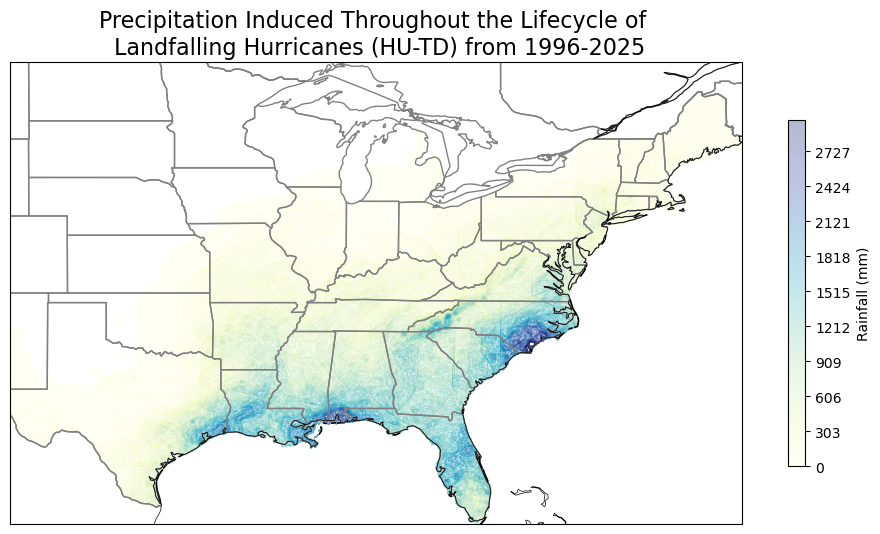

In [8]:
projection = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()

levels = np.linspace(0,3000,100)

plt.figure(figsize=(12,6))
ax = plt.subplot(111, projection=projection)

# Map features
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=1)
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='white')
ax.coastlines(resolution='50m', color='black', linewidth=0.5)
ax.set_extent([-105, -67, 25, 49], crs=ccrs.PlateCarree())


# Colorbar
cmap = plt.get_cmap(name='YlGnBu',lut=len(levels))

cs = ax.contourf(
    rain_total.lon,
    rain_total.lat,
    data_masked,
    levels=levels,
    transform=data_crs,
    cmap=cmap,
    alpha=0.3
)

cbar = plt.colorbar(cs, ax=ax, shrink=0.75)
cbar.set_label('Rainfall (mm)')
#cbar.ax.set_ylabel('Precipitation (inches)', weight='bold', size=14, style='italic')



plt.title('Precipitation Induced Throughout the Lifecycle of \n Landfalling Hurricanes (HU-TD) from 1996-2025', fontsize=16)
plt.savefig('PreliminaryResult.png',facecolor='w',dpi=400)

In [9]:
rain_avg_early = rain_early.mean(dim="storm", skipna=True)
rain_avg_late = rain_late.mean(dim="storm", skipna=True)

In [10]:
J,I = rain_avg_early.shape

In [11]:
comp_diff = rain_avg_late - rain_avg_early

n1 = len(rain_late.storm) # Number of late storms
n2 = len(rain_early.storm) # Number of early storms
dof = n1 + n2 - 2 # Degrees of freedom

s1 = rain_late.std(dim='storm', skipna=True) # late storms standard deviation
s2 = rain_early.std(dim='storm', skipna=True) # early storms standard deviation
sigma = (n1*pow(s1,2) + n2*pow(s2,2))/(n1+n2-1) # Pooled variance 

tStatistic = comp_diff/(np.sqrt(sigma)*np.sqrt(1/n1 + 1/n2)) # from in-class exercise

# p-value at each lat & lon for the two-sided t-test corresponding to each t-score.
pval = 2*stats.t.cdf(-abs(tStatistic),dof*np.ones(tStatistic.shape))


In [12]:
alpha = 0.05
stipple = (pval<=alpha) 
#======================================================
# Flatten the 2-D p-value array to 1-D for FDR testing.
# We will reuse pval_tscore from above.
#=======================================================================
alpha_FDR = 0.1  # Target FDR level (The percentage of incorrect rejections of the null hypothesis)
                  # Called gamma or q in the literature. Popular choice is 0.1 (10% incorrect rejections)
                  # But you can choose whatever level you want.

pval_flat = pval.flatten() 

mask = ~np.isnan(pval_flat)

adjusted = np.zeros_like(pval_flat)
adjusted[:] = np.nan

adjusted_valid = false_discovery_control(pval_flat[mask], axis=0, method='bh')
adjusted[mask] = adjusted_valid

#=======================================================================
# Apply the Benjamini–Hochberg FDR procedure in false_discovery_control, 
# which returns the adjusted p_values.
#=======================================================================


stipple_FDR = (adjusted < alpha_FDR).reshape(J, I)


#=======================================================================
# Report how many gridpoints are flagged as significant under each method.
#=======================================================================
n_total = J * I
n_tscore = np.sum(stipple) # standard t-test
n_fdr = np.sum(stipple_FDR)

print(f'Total gridpoints : {n_total}')
print(f'Significant (t-test alpha={alpha}): {n_tscore}  ({100*n_tscore/n_total:.1f}%)')
print(f'Significant (FDR  q={alpha_FDR}): {n_fdr}   ({100*n_fdr/n_total:.1f}%)')


#=======================================================================
# Find the effective p-value threshold used by BH
#=======================================================================
M = pval_flat.size

sorted_p = np.sort(pval_flat)
K = np.arange(1, pval_flat.size + 1) # ranks
bh_thresh_candidates = sorted_p[sorted_p <= (K / M) * alpha_FDR]
p_FDR_threshold = bh_thresh_candidates[-1] if bh_thresh_candidates.size > 0 else 0.0
print(f'BH p-value threshold used : {p_FDR_threshold:.5f}')


Total gridpoints : 525312
Significant (t-test alpha=0.05): 71834  (13.7%)
Significant (FDR  q=0.1): 70170   (13.4%)
BH p-value threshold used : 0.01058


In [13]:
lon, lat = np.meshgrid(comp_diff.lon, comp_diff.lat)

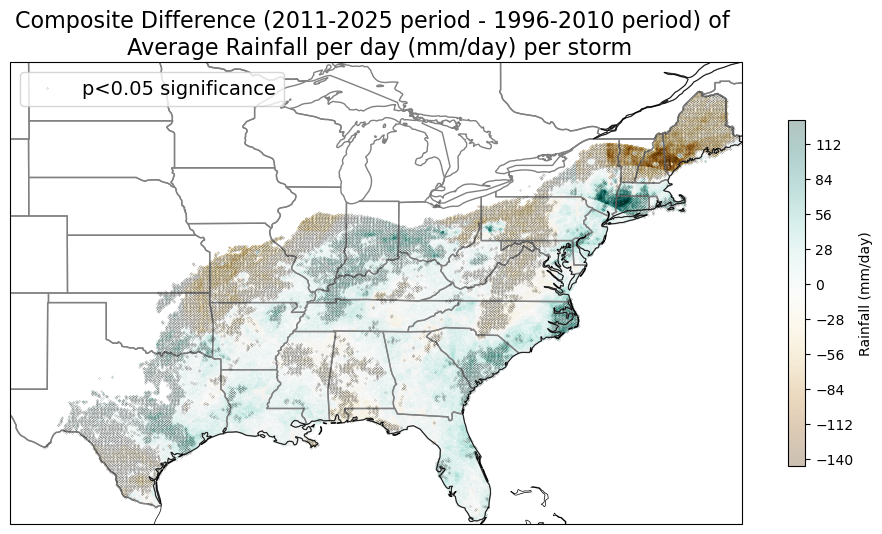

In [14]:
projection = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()

levels = np.arange(np.min(comp_diff),np.max(comp_diff),1)

plt.figure(figsize=(12,6))
ax = plt.subplot(111, projection=projection)

# Map features
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=1)
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='white')
ax.coastlines(resolution='50m', color='black', linewidth=0.5)
ax.set_extent([-105, -67, 25, 49], crs=ccrs.PlateCarree())


# Colorbar
cmap = plt.get_cmap(name='BrBG',lut=len(levels))

cs = ax.contourf(
    lon,
    lat,
    comp_diff,
    levels=levels,
    transform=data_crs,
    cmap=cmap,
    alpha=0.3
)

cbar = plt.colorbar(cs, ax=ax, shrink=0.75)
cbar.set_label('Rainfall (mm/day)')
#cbar.ax.set_ylabel('Precipitation (inches)', weight='bold', size=14, style='italic')

ax.plot(lon[stipple][::4],lat[stipple][::4],'o',color='black',markersize=0.1, transform=data_crs, label='p<0.05 significance') 
ax.legend(fontsize=14)

plt.title('Composite Difference (2011-2025 period - 1996-2010 period) of \n Average Rainfall per day (mm/day) per storm', fontsize=16)
plt.savefig('PreliminaryResult.png',facecolor='w',dpi=400)

In [ ]:
hh

